In [1]:
print('Importing relevant modules ...')
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pylab import rcParams
import matplotlib
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble'] = r'\boldmath'
rcParams['font.family'] = 'serif'
rc('text.latex',preamble=r'\usepackage{/Users/kevinlevy/Documents/cluster_lensing/files/apjfonts}')
from mpl_toolkits.axes_grid1 import make_axes_locatable
color_arr = ['olivedrab', 'steelblue', 'goldenrod']
import cosmo
import lensing
import lensing_estimator
import mockobs
import stats
import utils


#################################################################################################################################################
#%%


print('Defining relevant parameters ...')
nber_clus = 2500
nber_rand = 50000
cutout_size_am = 6
cutout_size_for_grad_est_am = 6
l_cut = 2000
average = 1
average_run = 1
nber_runs = 20
nx = 120
ny = 120
dx = 0.5
dy = 0.5
reso_arcmin = 0.5
map_params = [nx, dx, ny, dy]
beam_fwhm = 1.0 # arcmin
noiseval_white_arr = [0.1, 0.5, 1., 3., 5., 7.] # uK-arcmin
l = np.arange(10001)
cl = cosmo.cmb_power_spectra(l)['TT']
bl = mockobs.beam_power_spectrum(beam_fwhm, l)
nl_arr = []
cl_noise_arr = []
for noiseval_white in noiseval_white_arr:
    nl = mockobs.instrumental_noise_power_spectrum(noiseval_white, l)
    nl_arr.append(nl)
    cl_noise = mockobs.instrumental_noise_power_spectrum(noiseval_white, l, beam_fwhm)
    cl_noise_arr.append(cl_noise)

z = 0.7
mass_reso = 0.01
mass_min = 1.5
mass_max = 2.5
mass_int = np.arange(mass_min, mass_max, mass_reso)
M_input = 2e14

# for plotting
xmin, xmax = -nx*reso_arcmin/2, nx*reso_arcmin/2
ymin, ymax = -ny*reso_arcmin/2, ny*reso_arcmin/2 
extent_arcmin = [xmin, xmax, ymin, ymax]
extent_degrees = np.asarray(extent_arcmin)/60
fontsize = 19
labelsize = 15


save_loc_results = '/Users/kevinlevy/Documents/cluster_lensing/results/estimator_comparison'
if not os.path.exists(save_loc_results):
     os.makedirs(save_loc_results)   
    

Importing relevant modules ...
Defining relevant parameters ...


Checking likelhihood curves ...
2.0184537322052387 0.0037036705055670804
1.9896542744735726 0.006975640745337408
1.9736051325496717 0.010520206989843461
1.9658452344092352 0.022234122857308858
1.9685770249147785 0.03129532907254762
2.061563717591315 0.03967889546155057


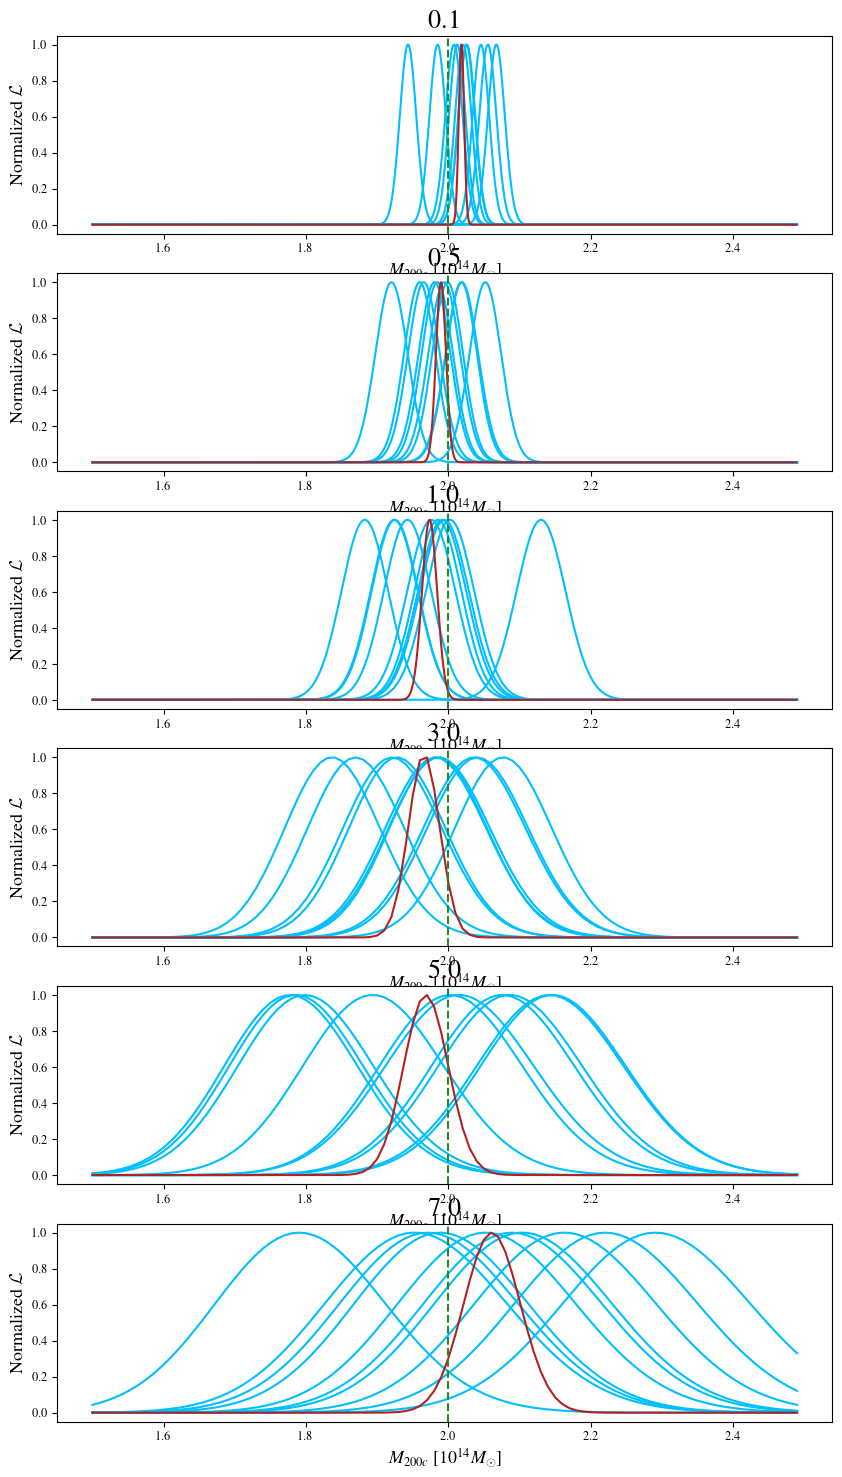

In [2]:
print('Checking likelhihood curves ...')
L_arr_sorted = np.load(save_loc_results+'/likelihoods.npy', allow_pickle=True)
L_ip_arr_sorted = np.load(save_loc_results+'/likelihoods_finer.npy', allow_pickle=True)
nber_runs = 10
s,e = 4, 14
L_arr_sorted = [L_arr_sorted[0][s:e], L_arr_sorted[1][s:e], L_arr_sorted[2][s:e], 
                L_arr_sorted[3][s:e], L_arr_sorted[4][s:e], L_arr_sorted[5][s:e]]

L_ip_arr_sorted = [L_ip_arr_sorted[0][s:e], L_ip_arr_sorted[1][s:e], L_ip_arr_sorted[2][s:e],
                   L_ip_arr_sorted[3][s:e], L_ip_arr_sorted[4][s:e], L_ip_arr_sorted[5][s:e]]
mass_int_finer = np.arange(min(mass_int),max(mass_int),0.001) 
comb_L_arr = []
comb_L_ip_arr = []
comb_median_mass_arr = []
comb_error_arr = []
for i in range(len(L_arr_sorted)):   
    if i in [0,1,2]:
        M_ip_comb, L_ip_comb, median_value_comb_finer, error_comb_finer = stats.combined_likelihood(mass_int_finer, L_ip_arr_sorted[i], normalize = True, finer_reso = False)
        print(median_value_comb_finer, error_comb_finer) 
        comb_L_ip_arr.append(L_ip_comb)
        comb_median_mass_arr.append(median_value_comb_finer)
        comb_error_arr.append(error_comb_finer)
    else:
        M_ip_comb, L_ip_comb, median_value_comb_finer, error_comb_finer = stats.combined_likelihood(mass_int, L_arr_sorted[i], normalize = True, finer_reso = False)
        print(median_value_comb_finer, error_comb_finer) 
        comb_L_ip_arr.append(L_ip_comb)
        comb_median_mass_arr.append(median_value_comb_finer)
        comb_error_arr.append(error_comb_finer)
combined_median_masses_results_file = ''
for i in range(len(comb_median_mass_arr)):
    combined_median_masses_results_file += "{0:11.2f}{1:>1}{2:5.2f}".format(comb_median_mass_arr[i], "+-", comb_error_arr[i]) + "\n"  
file = open(save_loc_results+'/mass_results.txt',"w")
file.write(combined_median_masses_results_file)
file.close()



nber_runs_check = nber_runs
start = 0
end = 10000
start_finer = 0
end_finer = 10000

fig, axarr = plt.subplots(len(L_arr_sorted), 1, figsize=(10,18))
titles = [str(noiseval_white_arr[0]), str(noiseval_white_arr[1]), str(noiseval_white_arr[2]), 
          str(noiseval_white_arr[3]), str(noiseval_white_arr[4]), str(noiseval_white_arr[5])]


for i in range(len(axarr)):
    titstr = titles[i]
    axarr[i].set_title(titstr, fontsize = fontsize)
    for j in  range(nber_runs_check):
        if i in [3,4,5]:
            axarr[i].plot(mass_int, L_arr_sorted[i][j], ls = '-', marker = '', color = 'deepskyblue')  
        else:
            axarr[i].plot(mass_int_finer, L_ip_arr_sorted[i][j], ls = '-', marker = '', color = 'deepskyblue')   
    if i in [3,4,5]:
        axarr[i].plot(mass_int, comb_L_ip_arr[i], ls = '-', marker = '', color = 'firebrick')
    else:    
        axarr[i].plot(mass_int_finer[:990], comb_L_ip_arr[i][:990], ls = '-', marker = '', color = 'firebrick')
    axarr[i].axvline(M_input*1e-14, color = 'forestgreen', ls = '--')
    axarr[i].set_xlabel(r'$M_{200c} \ [10^{14}M_\odot]$', fontsize = fontsize-6)
    axarr[i].set_ylabel('Normalized '+r'$\mathcal{L}$', fontsize = fontsize-6)
    axarr[i].tick_params(labelsize = labelsize-6)
plt.show()
fig.savefig(save_loc_results+'/likelihoods_check.eps', dpi = 200., bbox_inches = 'tight', pad_inches = 0.1)    


In [3]:
fontsize = 17
labelsize = 15
legendsize = 14

[0.00586379 0.01099575 0.01676427 0.03480446 0.04940617 0.06179497]
[0.00011914 0.00018377 0.00024622 0.00066733 0.00130543 0.00146973]
[0.00185429 0.00347716 0.00530133 0.01100614 0.0156236  0.01954129]
[3.76753760e-05 5.81131766e-05 7.78616005e-05 2.11028275e-04
 4.12813213e-04 4.64769435e-04]


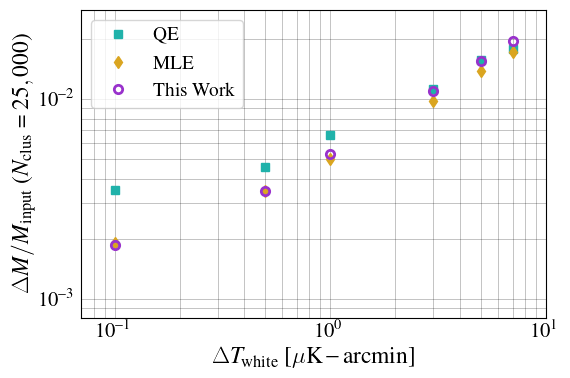

In [81]:
median_error_arr_sorted = np.load(save_loc_results+'/error_results.npy')
nber_runs = 10
s,e = 0, 10
median_error_arr_sorted = [median_error_arr_sorted[0][s:e], median_error_arr_sorted[1][s:e], median_error_arr_sorted[2][s:e],
                           median_error_arr_sorted[3][s:e], median_error_arr_sorted[4][s:e], median_error_arr_sorted[5][s:e]]

frac_mass_unc_arr = np.asarray(np.mean(median_error_arr_sorted, axis = 1))/(M_input*1e-14) #/np.asarray(comb_median_mass_arr)
frac_err_unc_arr = np.asarray(np.std(median_error_arr_sorted, axis = 1))/(M_input*1e-14) #/np.asarray(comb_median_mass_arr)

my_arr = np.asarray(frac_mass_unc_arr)
my_err = np.asarray(frac_err_unc_arr)
print(my_arr)
print(my_err)
scal_fac = np.sqrt(nber_clus/(nber_clus*nber_runs))
for i in range(len(my_arr)):
    my_arr[i] = np.round(my_arr[i], 8)*scal_fac
    my_err[i] = np.round(my_err[i], 8)*scal_fac
print(my_arr)
print(my_err)  
np.save(save_loc_results+'/fractional_mass_uncertainties.npy', my_arr)
np.save(save_loc_results+'/fractional_error_uncertainties.npy', my_err)

scal_fac = np.sqrt(100000./(nber_runs*nber_clus))
qe_arr =  np.asarray([0.0175118, 0.02292831, 0.03323149, 0.05606527, 0.07843721, 0.08927969])*1e-1*scal_fac
mle_arr = np.asarray([0.0095446, 0.01742045, 0.0251993, 0.04917473, 0.06890442, 0.0864266])*1e-1*scal_fac
fig, ax = plt.subplots( figsize=(6, 4))
ax.set_xscale('log')
ax.set_yscale('log')
color_arr = ['darkorchid', 'lightseagreen', 'goldenrod']
#ax.errorbar(noiseval_white_arr, my_arr, my_err, color = color_arr[0], ls = '', marker = 'o', markersize = 6.5, elinewidth = 2.5, label = 'This Work')

ax.plot(noiseval_white_arr, qe_arr, color = color_arr[1], ls = '', marker = 's', markersize = 6., label = 'QE',  alpha = 1.)
ax.plot(noiseval_white_arr, mle_arr, color = color_arr[2], ls = '', marker = 'd', markersize = 6., label = 'MLE',  alpha = 1.)
ax.plot(noiseval_white_arr, my_arr, color = color_arr[0], ls = '', marker = 'o', markersize = 6., label = 'This Work', alpha = 1., mfc = 'None', markeredgewidth = 2.0)

ax.set_xlabel(r'$\Delta T_{\rm white}\ [\mu \rm K- \rm arcmin]$', fontsize = fontsize)
ax.set_ylabel(r'$\Delta M/M_{\rm input}$ $(N_{{\rm clus}} = 25,000)$', fontsize = fontsize)
ax.tick_params(direction='in', axis='both', length=0, width=0, which = 'major', top = 'on', bottom = 'on', left = 'on', right = 'on', labelsize = labelsize)
ax.tick_params(direction='in', axis='both', length=0, width=0, which = 'minor', top = 'on', bottom = 'on', left = 'on', right = 'on', labelsize = labelsize)
ax.legend(ncol = 1, prop={'size': legendsize}, loc = 'upper left') 
#ax.set_ylim(0.0005, 0.015)
ax.set_xlim(0.07, 10)
ax.set_ylim(8e-4, 2.8e-2)
ax.grid(which = 'both', axis = 'both', lw = 0.5, alpha = 0.33, color = 'black')
plt.show()
fig.savefig(save_loc_results+'/estimator_comparison.pdf', dpi = 200., bbox_inches = 'tight', pad_inches = 0.1)

In [61]:
noiseval_white_arr

[0.1, 0.5, 1.0, 3.0, 5.0, 7.0]

In [16]:
my_arr

array([0.00185429, 0.00347716, 0.00530133, 0.01100614, 0.0156236 ,
       0.01954129])

In [17]:
qe_arr 

array([0.00350236, 0.00458566, 0.0066463 , 0.01121305, 0.01568744,
       0.01785594])

In [18]:
mle_arr

array([0.00190892, 0.00348409, 0.00503986, 0.00983495, 0.01378088,
       0.01728532])

In [19]:
my_arr/mle_arr

array([0.97138341, 0.99801138, 1.05187994, 1.1190846 , 1.13371557,
       1.13051337])

In [20]:
my_arr/qe_arr

array([0.52944107, 0.75826815, 0.79763617, 0.98154674, 0.99593055,
       1.09438582])

In [21]:
mle_arr/qe_arr

array([0.5450382 , 0.75977907, 0.75829582, 0.87709789, 0.87846597,
       0.96804324])